In [1]:
# Bibliotecas básicas
import mlflow
import pandas as pd
import numpy as np
import random

import warnings

warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import dagshub

# Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Grid Search
import itertools

# Funções auxiliares
from utils import *

In [2]:
# Test Size
TEST_SIZE = 0.2
EXPERIMENT_NAME = "Churn"

In [3]:
df_raw = pd.read_csv('../data/dataset/telco_customer_churn.csv')
df = df_raw.copy()
df.rename(columns={'Churn': 'target'}, inplace=True)
# Converter target para binário (0 = sem churn, 1 = com churn)
df['target'] = df['target'].map({'Yes': 1, 'No': 0})

df_encoded = preprocessing(df)
X_train_encoded, X_test_encoded, y_train, y_test = prepare_train_val_test(df_encoded, test_size=TEST_SIZE, random_state=SEED, mode='baseline')

Colunas categóricas (3): ['Contract', 'PaymentMethod', 'tenure_bucket']

  Contract: 3 valores únicos → ['Month-to-month' 'One year' 'Two year']
  PaymentMethod: 4 valores únicos → ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
  tenure_bucket: 4 valores únicos → ['0-12', '25-48', '13-24', '49+']
Categories (4, object): ['0-12' < '13-24' < '25-48' < '49+']


In [4]:
dagshub.init(repo_owner='JosueJNLui', repo_name='fiap-mlet-challenge-fase-1', mlflow=True)
mlflow.set_experiment(EXPERIMENT_NAME)

Accessing as JosueJNLui

Initialized MLflow to track repo "JosueJNLui/fiap-mlet-challenge-fase-1"

Repository JosueJNLui/fiap-mlet-challenge-fase-1 initialized!

<Experiment: artifact_location='mlflow-artifacts:/313d7081df3240a7925daedda6d4969c', creation_time=1775940203269, experiment_id='0', last_update_time=1775940203269, lifecycle_stage='active', name='Churn', tags={'mlflow.experimentKind': 'custom_model_development'}, workspace='default'>

# Etapa 01 - Baselines

Dataset MD5: 0f9de68e012bd3aed5fa7cdc9fc421af


2026/04/20 14:43:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/20 14:43:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'DummyClassifier' already exists. Creating a new version of this model...
2026/04/20 14:43:50 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: DummyClassifier, version 16
Created version '16' of model 'DummyClassifier'.
2026/04/20 14:44:02 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-c55d7d11c


 DummyClassifier
              precision    recall  f1-score   support

   Sem churn       0.73      1.00      0.85      1035
   Com churn       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

  ROC-AUC:  0.5000
  PR-AUC:   0.6327
  TP Custo churn evitado: R$ 0
  FN Custo churn perdido: R$ 187,000
  FP Custo falso positivo: R$ 0
  💰 Lucro Líquido: R$ 0
🏃 View run DummyClassifier at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/0/runs/3ea47fd722c84ec3a66cee97b7251a8f
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/0


2026/04/20 14:44:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/20 14:44:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'LogisticRegression' already exists. Creating a new version of this model...
2026/04/20 14:44:52 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: LogisticRegression, version 14
Created version '14' of model 'LogisticRegression'.
2026/04/20 14:45:04 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-


 LogisticRegression
              precision    recall  f1-score   support

   Sem churn       0.91      0.73      0.81      1035
   Com churn       0.51      0.80      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

  ROC-AUC:  0.8473
  PR-AUC:   0.6660
  TP Custo churn evitado: R$ 119,200
  FN Custo churn perdido: R$ 38,000
  FP Custo falso positivo: R$ 28,200
  💰 Lucro Líquido: R$ 91,000
🏃 View run LogisticRegression at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/0/runs/ea62766d69364908a3cedad0f95ee0aa
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/0


<Figure size 1050x700 with 0 Axes>

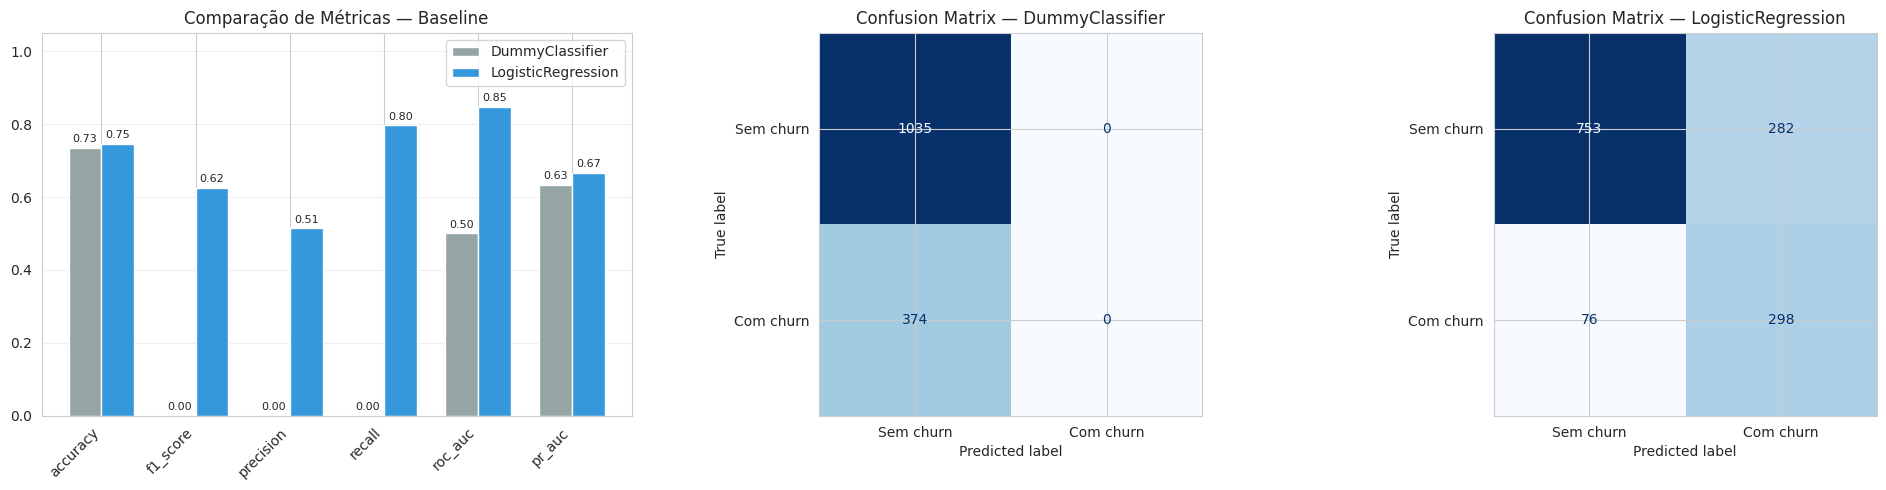


 RESUMO DOS BASELINES
                 Métrica  DummyClassifier  LogisticRegression
                accuracy         0.734564            0.745919
                f1_score         0.000000            0.624738
               precision         0.000000            0.513793
                  recall         0.000000            0.796791
                 roc_auc         0.500000            0.847263
                  pr_auc         0.632718            0.665958
 custo_churn_evitado_BRL         0.000000       119200.000000
custo_falso_positivo_BRL         0.000000        28200.000000
 custo_churn_perdido_BRL    187000.000000        38000.000000
       lucro_liquido_BRL         0.000000        91000.000000

✅ Experimentos registrados no MLflow (experiment: Churn)


In [5]:
# =============================================================================
# BASELINE: DummyClassifier + Regressão Logística com MLflow
# =============================================================================
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import hashlib

# --- Metadados do dataset para versionamento ---
DATASET_PATH = "../data/dataset/telco_customer_churn.csv"

with open(DATASET_PATH, "rb") as f:
    DATASET_VERSION = hashlib.md5(f.read()).hexdigest()

print(f"Dataset MD5: {DATASET_VERSION}")

dataset_params = {
    "dataset_path": DATASET_PATH,
    "dataset_version_md5": DATASET_VERSION,
    "n_train": X_train_encoded.shape[0],
    "n_test": X_test_encoded.shape[0],
    "n_features": X_train_encoded.shape[1],
    "target_rate_train": round(y_train.mean(), 4),
    "test_size": TEST_SIZE,
    "random_state": SEED,
    "imputation_strategy": "median",
    "encoding": "one_hot_drop_first",
}


# --- Dataset MLflow para rastreabilidade na UI ---
mlflow_train_dataset = mlflow.data.from_pandas(
    X_train_encoded.assign(Churn=y_train),
    source=DATASET_PATH,
    name="telco_customer_churn_train",
    targets="Churn",
)

mlflow_test_dataset = mlflow.data.from_pandas(
    X_test_encoded.assign(Churn=y_test),
    source=DATASET_PATH,
    name="telco_customer_churn_test",
    targets="Churn",
)


def evaluate_and_log(model, model_name, X_tr, y_tr, X_te, y_te, extra_params=None):
    """Treina o modelo, avalia e registra tudo no MLflow."""
    with mlflow.start_run(run_name=model_name):
        # --- Treinar ---
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        # Probabilidades (DummyClassifier com most_frequent retorna prob constante)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_te)[:, 1]
        else:
            y_proba = np.zeros(len(y_te))

        # --- Métricas ---
        acc = accuracy_score(y_te, y_pred)
        f1 = f1_score(y_te, y_pred, pos_label=1)
        prec = precision_score(y_te, y_pred, pos_label=1, zero_division=0)
        rec = recall_score(y_te, y_pred, pos_label=1)
        roc_auc = roc_auc_score(y_te, y_proba) if y_proba.sum() > 0 else 0.5
        pr_precision, pr_recall, _ = precision_recall_curve(y_te, y_proba)
        pr_auc = auc(pr_recall, pr_precision)

        metrics = {
            "accuracy": acc,
            "f1_score": f1,
            "precision": prec,
            "recall": rec,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
        }

        # --- Métrica de negócio avançada: ROI e Lucro Líquido ---
        VALOR_CLIENTE_LTV = 500   # O que ganhamos ao reter um TP
        CUSTO_RETENCAO = 100      # O custo da oferta (desconto/cupom) para TP e FP

        # Extrair valores da matriz de confusão
        cm = confusion_matrix(y_te, y_pred)
        tn, fp, fn, tp = cm.ravel()

        # 1. Ganho com acertos (TP): Retivemos quem ia sair
        ganho_tp = tp * (VALOR_CLIENTE_LTV - CUSTO_RETENCAO)

        # 2. Custo do erro de alarme falso (FP): Gastamos com quem já ia ficar
        custo_fp = fp * CUSTO_RETENCAO

        # 3. Custo do churn não detectado (FN): Perdemos o cliente por omissão
        perda_fn = fn * VALOR_CLIENTE_LTV

        # Lucro Líquido da Campanha
        lucro_liquido = ganho_tp - custo_fp
        
        # Adicionar ao dicionário de métricas para log
        metrics["custo_churn_evitado_BRL"] = ganho_tp
        metrics["custo_falso_positivo_BRL"] = custo_fp
        metrics["custo_churn_perdido_BRL"] = perda_fn
        metrics["lucro_liquido_BRL"] = lucro_liquido

        # --- Log no MLflow ---
        mlflow.log_input(mlflow_train_dataset, context="training")
        mlflow.log_input(mlflow_test_dataset, context="testing")
        mlflow.log_params(dataset_params)
        if extra_params:
            mlflow.log_params(extra_params)
        mlflow.log_metrics(metrics)
        mlflow.set_tag("model_type", model_name)
        model_info = mlflow.sklearn.log_model(
            model,
            name="baseline",
            registered_model_name=model_name,
        )

        # --- Evaluate: vincula dataset ao modelo registrado ---
        eval_data = X_te.assign(Churn=y_te)
        mlflow.evaluate(
            model=model_info.model_uri,
            data=eval_data,
            targets="Churn",
            model_type="classifier",
            dataset_path=DATASET_PATH,
        )

        # --- Print ---
        print(f"\n{'='*60}")
        print(f" {model_name}")
        print(f"{'='*60}")
        print(classification_report(y_te, y_pred, target_names=["Sem churn", "Com churn"]))
        print(f"  ROC-AUC:  {roc_auc:.4f}")
        print(f"  PR-AUC:   {pr_auc:.4f}")
        print(f"  TP Custo churn evitado: R$ {ganho_tp:,.0f}")
        print(f"  FN Custo churn perdido: R$ {perda_fn:,.0f}")
        print(f"  FP Custo falso positivo: R$ {custo_fp:,.0f}")
        print(f"  💰 Lucro Líquido: R$ {lucro_liquido:,.0f}")

    return metrics, cm


# =============================================================================
# 1. DummyClassifier (baseline ingênuo — sempre prediz a classe majoritária)
# =============================================================================
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy_params = {"strategy": "most_frequent"}
dummy_metrics, dummy_cm = evaluate_and_log(
    dummy, "DummyClassifier", X_train_encoded, y_train, X_test_encoded, y_test,
    extra_params=dummy_params
)

# =============================================================================
# 2. Regressão Logística (baseline com class_weight='balanced')
# =============================================================================
lr = LogisticRegression(
    max_iter=1000, random_state=SEED, class_weight="balanced", solver="lbfgs"
)
lr_params = {
    "C": lr.C,
    "solver": lr.solver,
    "max_iter": lr.max_iter,
    "class_weight": "balanced",
    "balancing_technique": "class_weight_balanced",
}
lr_metrics, lr_cm = evaluate_and_log(
    lr, "LogisticRegression", X_train_encoded, y_train, X_test_encoded, y_test,
    extra_params=lr_params
)

# =============================================================================
# COMPARAÇÃO VISUAL
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Métricas lado a lado
metric_names = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]
dummy_vals = [dummy_metrics[m] for m in metric_names]
lr_vals = [lr_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35
bars1 = axes[0].bar(x - width/2, dummy_vals, width, label="DummyClassifier", color="#95a5a6")
bars2 = axes[0].bar(x + width/2, lr_vals, width, label="LogisticRegression", color="#3498db")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=45, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Comparação de Métricas — Baseline")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

# 2. Confusion Matrix — DummyClassifier
ConfusionMatrixDisplay(dummy_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title("Confusion Matrix — DummyClassifier")

# 3. Confusion Matrix — Logistic Regression
ConfusionMatrixDisplay(lr_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[2], cmap="Blues", colorbar=False
)
axes[2].set_title("Confusion Matrix — LogisticRegression")

plt.tight_layout()
plt.show()

# --- Resumo final ---
print("\n" + "="*60)
print(" RESUMO DOS BASELINES")
print("="*60)
resumo = pd.DataFrame({
    "Métrica": metric_names + ["custo_churn_evitado_BRL", "custo_falso_positivo_BRL", "custo_churn_perdido_BRL", "lucro_liquido_BRL"],
    "DummyClassifier": dummy_vals + [dummy_metrics["custo_churn_evitado_BRL"], dummy_metrics["custo_falso_positivo_BRL"], dummy_metrics["custo_churn_perdido_BRL"], dummy_metrics["lucro_liquido_BRL"]],
    "LogisticRegression": lr_vals + [lr_metrics["custo_churn_evitado_BRL"], lr_metrics["custo_falso_positivo_BRL"], lr_metrics["custo_churn_perdido_BRL"], lr_metrics["lucro_liquido_BRL"]],
})
print(resumo.to_string(index=False))

print(f"\n✅ Experimentos registrados no MLflow (experiment: {EXPERIMENT_NAME})")

# Etapa 02 - MLP

In [7]:
df_encoded = preprocessing(df)
X_train_encoded, X_val_encoded, X_test_encoded, y_train, y_val, y_test = prepare_train_val_test(df_encoded, test_size=TEST_SIZE, random_state=SEED)

# Converte tudo para float32 e garante que as dimensões estão corretas para PyTorch
X_train_tensor = torch.tensor(X_train_encoded.values.astype(np.float32))
X_val_tensor   = torch.tensor(X_val_encoded.values.astype(np.float32))
X_test_tensor  = torch.tensor(X_test_encoded.values.astype(np.float32))
y_train_tensor = torch.tensor(y_train.values.astype(np.float32)).unsqueeze(1)
y_val_tensor   = torch.tensor(y_val.values.astype(np.float32)).unsqueeze(1)
y_test_tensor  = torch.tensor(y_test.values.astype(np.float32)).unsqueeze(1)

# Sincroniza X e y em um único objeto, garantindo que andem juntos e na mesma ordem
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# Input Dimension: número de features
input_dim = X_train_tensor.shape[1]


print(f"Features de entrada: {input_dim}")

Colunas categóricas (3): ['Contract', 'PaymentMethod', 'tenure_bucket']

  Contract: 3 valores únicos → ['Month-to-month' 'One year' 'Two year']
  PaymentMethod: 4 valores únicos → ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
  tenure_bucket: 4 valores únicos → ['0-12', '25-48', '13-24', '49+']
Categories (4, object): ['0-12' < '13-24' < '25-48' < '49+']
Features de entrada: 22


In [8]:
# Grid Search com Nested Runs

param_grid = {
    "lr":          [1e-2, 1e-3, 1e-4],
    "dropout":     [0.2, 0.3],
    "batch_size":  [32, 64, 128],
    "hidden_dims": [(64, 32), (32, 16)]
}

# Valores fixos
PATIENCE     = 10
EPOCHS       = 100
OPTIMIZER    = "Adam"
ACTIVATION   = "ReLU"

# pos_weight: equivalente ao class_weight='balanced'
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)

# Gera todas as combinações
combinations = list(itertools.product(*param_grid.values()))
print(f"Total de combinações: {len(combinations)}")

Total de combinações: 36


In [9]:
class ChurnMLP(nn.Module):
    """MLP com arquitetura e hiperparâmetros configuráiveis para grid search."""

    def __init__(self, input_dim: int, hidden_dims: tuple, dropout: float):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for h_dim in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h_dim),
                nn.ReLU(),
                nn.BatchNorm1d(h_dim),
                nn.Dropout(dropout)
            ]
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    
    def forward(self, x):
        return self.network(x)

In [10]:
def train_mlp(model, train_loader: DataLoader, val_loader: DataLoader,
              criterion, optimizer, patience: int = 10, epochs: int = 100):
    """Treina a MLP com early stopping e retorna o histórico de loss."""

    best_val_loss = float("inf")
    best_weights = None
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):

        # --- Treino ---
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()                 # Zera gradientes acumulados
            preds = model(X_batch)                # Forward: calcula saída para todas as entradas
            loss = criterion(preds, y_batch)      # Calcula o erro (loss) em relação ao esperado
            loss.backward()                       # Backpropagation: gradiente dos pesos
            optimizer.step()                      # Atualiza os pesos (descida do gradiente)
            train_loss += loss.item()             # Acumula o valor do loss
        
        train_loss /= len(train_loader) # Média do loss por batch
    
        # --- Validação ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                val_loss += loss.item()
        val_loss /= len(val_loader)
    
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if epoch % 10 == 0:
            print(f"Epoch: {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss {val_loss:.4f}")
        
        # --- Early Stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⏹ Early stopping na epoch: {epoch} (patience={patience})")
                break
    
    model.load_state_dict(best_weights)
    print(f"\n✅ Melhor val_loss: {best_val_loss:.4f}")
    return history            

In [11]:
def run_single_experiment(lr: float, dropout: float, batch_size: int, hidden_dims: tuple, parent_run_id):
    """Treina e avalia uma combinação com nested run."""

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = ChurnMLP(input_dim, hidden_dims, dropout)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = train_mlp(
        model, train_loader, val_loader, criterion, optimizer, patience=PATIENCE, epochs=EPOCHS
    )

    # --- Avaliação ---
    model.eval()
    with torch.no_grad():
        y_proba = torch.sigmoid(model(X_test_tensor)).numpy().flatten()
        y_pred = (y_proba >= 0.3).astype(int)

    
    f1      = f1_score(y_test, y_pred, pos_label=1)
    prec    = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec     = recall_score(y_test, y_pred, pos_label=1)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_prec_, pr_rec_, _ = precision_recall_curve(y_test, y_proba)
    pr_auc  = auc(pr_rec_, pr_prec_)

    # --- Métrica de negócio avançada: ROI e Lucro Líquido ---
    VALOR_CLIENTE_LTV = 500   # O que ganhamos ao reter um TP
    CUSTO_RETENCAO = 100      # O custo da oferta (desconto/cupom) para TP e FP

    # Extrair valores da matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # 1. Ganho com acertos (TP): Retivemos quem ia sair
    ganho_tp = tp * (VALOR_CLIENTE_LTV - CUSTO_RETENCAO)

    # 2. Custo do erro de alarme falso (FP): Gastamos com quem já ia ficar
    custo_fp = fp * CUSTO_RETENCAO

    # 3. Custo do churn não detectado (FN): Perdemos o cliente por omissão
    perda_fn = fn * VALOR_CLIENTE_LTV

    # Lucro Líquido da Campanha
    lucro_liquido = ganho_tp - custo_fp


    metrics = {
        "accuracy":                accuracy_score(y_test, y_pred),
        "f1_score":                f1,
        "precision":               prec,
        "recall":                  rec,
        "roc_auc":                 roc_auc,
        "pr_auc":                  pr_auc,
        "best_val_loss":           min(history["val_loss"]),
        "epochs_trained":          len(history["train_loss"]),
    }

    # Adicionar ao dicionário de métricas para log
    metrics["custo_churn_evitado_BRL"] = ganho_tp
    metrics["custo_falso_positivo_BRL"] = custo_fp
    metrics["custo_churn_perdido_BRL"] = perda_fn
    metrics["lucro_liquido_BRL"] = lucro_liquido

    run_name = f"lr={lr}_dropout={dropout}_batch={batch_size}_hidden_dims={hidden_dims}"
    with mlflow.start_run(run_name=run_name, nested=True, parent_run_id=parent_run_id):
        mlflow.log_params({
            "lr":           lr,
            "dropout":      dropout,
            "batch_size":   batch_size,
            "hidden_dims":  str(hidden_dims),
            "patience":     PATIENCE,
            "epochs_max":   EPOCHS,
            "optimizer":    OPTIMIZER,
            "activation":   ACTIVATION,
            "pos_weight":   round(pos_weight.item(), 2),
        })
        mlflow.log_metrics(metrics)
        mlflow.set_tag("model_type", "ChurnMLP_tuning")

        for i, (tl, vl) in enumerate(zip(history["train_loss"], history["val_loss"])):
            mlflow.log_metric("train_loss", tl, step=i)
            mlflow.log_metric("val_loss",   vl, step=i)

    return metrics, run_name

In [12]:
# Run PAI

with mlflow.start_run(run_name="ChurnMLP_GridSearch") as parent_run:

    mlflow.set_tag("tuning_strategy", "grid_search")
    mlflow.set_tag("model_type",      "ChurnMLP")
    mlflow.log_params({
        "total_combinations": len(combinations),
        "search_lr":          str(param_grid["lr"]),
        "search_dropout":     str(param_grid["dropout"]),
    })

    results = []
    for i, (lr, dropout, batch_size, hidden_dims) in enumerate(combinations):
        print(f"\n[{i+1}/{len(combinations)}] lr={lr} | dropout={dropout} | batch_size={batch_size} | hidden_dims={hidden_dims}")
        try:
            metrics, run_name = run_single_experiment(lr, dropout, batch_size, hidden_dims, parent_run.info.run_id)
            results.append({"lr": lr, "dropout": dropout, "batch_size": batch_size, "hidden_dims": hidden_dims, "metrics": metrics})
            print(f"  f1={metrics['f1_score']:.4f} | recall={metrics['recall']:.4f} | roc_auc={metrics['roc_auc']:.4f}")
        except Exception as e:
            print(f"  ❌ Falhou: {e}")
            continue

    # Melhor combinação
    best = max(results, key=lambda r: r["metrics"]["recall"])
    print(f"\n{'='*60}")
    print(f" MELHOR — lr={best['lr']} | dropout={best['dropout']}")
    print(f" recall={best['metrics']['recall']:.4f} | f1={best['metrics']['f1_score']:.4f}")
    print(f"  TP Custo churn evitado: R$ {best['metrics']['custo_churn_evitado_BRL']:,.0f}")
    print(f"  FN Custo churn perdido: R$ {best['metrics']['custo_churn_perdido_BRL']:,.0f}")
    print(f"  FP Custo falso positivo: R$ {best['metrics']['custo_falso_positivo_BRL']:,.0f}")
    print(f"  💰 Lucro Líquido: R$ {best['metrics']['lucro_liquido_BRL']:,.0f}")
    print(f"{'='*60}")

    mlflow.log_params({
        "best_lr":      best["lr"],
        "best_dropout": best["dropout"],
        "best_batch_size": best["batch_size"],
        "best_hidden_dims": best["hidden_dims"]
    })
    mlflow.log_metrics({f"best_{k}": v for k, v in best["metrics"].items()})


[1/36] lr=0.01 | dropout=0.2 | batch_size=32 | hidden_dims=(64, 32)
Epoch:  10 | Train Loss: 0.7260 | Val Loss 0.7253

⏹ Early stopping na epoch: 13 (patience=10)

✅ Melhor val_loss: 0.7168
🏃 View run lr=0.01_dropout=0.2_batch=32_hidden_dims=(64, 32) at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/0/runs/ae55a11453344582a879a0363946e30c
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/0
  f1=0.5574 | recall=0.9545 | roc_auc=0.8418

[2/36] lr=0.01 | dropout=0.2 | batch_size=32 | hidden_dims=(32, 16)
Epoch:  10 | Train Loss: 0.7332 | Val Loss 0.7223

⏹ Early stopping na epoch: 14 (patience=10)

✅ Melhor val_loss: 0.7156
🏃 View run lr=0.01_dropout=0.2_batch=32_hidden_dims=(32, 16) at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/0/runs/ea390765a1f7430daac433c285b2c515
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/0

TESTE GABRIEL 
1. Função de avaliação (reutilizável)

In [13]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, precision_recall_curve, auc, confusion_matrix
)

def evaluate_model(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)

    pr_prec, pr_rec, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(pr_rec, pr_prec)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    CUSTO_CHURN = 500

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_score": f1,
        "precision": prec,
        "recall": rec,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "false_positive": fp,
        "false_negative": fn,
        "churn_evitado_BRL": tp * CUSTO_CHURN,
        "churn_perdido_BRL": fn * CUSTO_CHURN,
    }

    return metrics

2. Baselines (Scikit-Learn)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def train_baselines(X_train, y_train, X_test):
    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "RandomForest": RandomForestClassifier(n_estimators=100)
    }

    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]

        results[name] = y_proba

    return results

3. Predição da MLP (usar seu modelo já treinado)

In [15]:
def predict_mlp(model, X_test_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_test_tensor)
        probs = torch.sigmoid(logits).numpy().flatten()
    return probs

4. Comparação + MLflow (parte principal)

In [16]:
import mlflow

def compare_models(X_train, y_train, X_test, y_test, model_mlp, X_test_tensor):

    with mlflow.start_run(run_name="Model_Comparison"):

        all_results = []

        # ------------------------
        # Baselines
        # ------------------------
        baseline_preds = train_baselines(X_train, y_train, X_test)

        for name, y_proba in baseline_preds.items():
            metrics = evaluate_model(y_test, y_proba, threshold=0.5)

            mlflow.log_metrics({f"{name}_{k}": v for k, v in metrics.items()})
            mlflow.set_tag(f"{name}_type", "baseline")

            all_results.append({"model": name, **metrics})

        # ------------------------
        # MLP
        # ------------------------
        y_proba_mlp = predict_mlp(model_mlp, X_test_tensor)

        # usar threshold mais agressivo (churn)
        metrics_mlp = evaluate_model(y_test, y_proba_mlp, threshold=0.3)

        mlflow.log_metrics({f"MLP_{k}": v for k, v in metrics_mlp.items()})
        mlflow.set_tag("MLP_type", "neural_network")

        all_results.append({"model": "MLP", **metrics_mlp})

        return all_results

5. Exibir resultado final (tabela simples)

In [17]:
import pandas as pd

def show_results(results):
    df = pd.DataFrame(results)
    df = df.sort_values(by="recall", ascending=False)

    print("\n📊 Comparação de Modelos:")
    print(df[[
        "model", "recall", "precision", "f1_score",
        "roc_auc", "churn_evitado_BRL", "churn_perdido_BRL"
    ]])

    return df

Execução final

In [ ]:
results = compare_models(
    X_train_encoded,
    y_train,
    X_test_encoded,
    y_test,
    model,  # sua MLP já treinada
    X_test_tensor
)

df_results = show_results(results)

In [ ]:
# === FIXES ADDED ===
import random, numpy as np, torch
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

from sklearn.model_selection import train_test_split

# Ajuste de split correto
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42)

print('✔ Ajustes aplicados: seed + validação correta')